<h1><center>TYPE 1 - TRAINING MODEL WITHOUT REDUCING THE DIMENSION</h1></center>

<h3>STEP 1 – Load Reduced Dataset</h3>

In [31]:
import pandas as pd

data = pd.read_csv(r'D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\Data\processed_03\cicids2017_merged.csv')

print(data.shape)

(2520751, 81)


</h3>STEP 2 – Separate X and y</h3>

In [32]:
X = data.drop('Encoded_Label', axis=1)
y = data['Encoded_Label']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2520751, 80)
y shape: (2520751,)


<h3>STEP 3 – Scale (float32 for memory efficiency)</h3>

In [33]:
from sklearn.preprocessing import StandardScaler
import joblib
import numpy as np

# Ensure X only contains numeric features
X = X.select_dtypes(include=[np.number]).astype(np.float32)

# Fit and transform with StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save the scaler for later use
joblib.dump(scaler, r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\scaler.pkl")

print("Scaling complete. Scaler saved successfully.")

Scaling complete. Scaler saved successfully.


<h3>STEP 4 – Train / Validation / Test Split</h3>

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1764525, 78)
Validation: (378113, 78)
Test: (378113, 78)


<h3>STEP 5 – Compute & Clamp Class Weights</h3>

In [35]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

# Clamp extreme weights to prevent instability
class_weights_dict = {
    k: min(v, 50)
    for k, v in class_weights_dict.items()
}

print("Final Class Weights:")
print(class_weights_dict)

Final Class Weights:
{0: np.float64(0.17188427992709365), 1: 50, 2: np.float64(39.3559718969555), 3: np.float64(2.8130231001004353), 4: np.float64(1.8586723295064924), 5: np.float64(3.9705604385218787), 6: 50}


<h3>STEP 6 – Reshape for RNN</h3>

In [36]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val   = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("Reshaped Train:", X_train.shape)

Reshaped Train: (1764525, 78, 1)


<h3>STEP 7 - Build RNN with input shape of 78</h3>

In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

num_classes = 7

model = Sequential([
    Input(shape=(78,1)),
    
    SimpleRNN(64, activation='tanh'),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    Dropout(0.3),
    
    Dense(num_classes, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005,   # Reduced LR
    clipnorm=1.0            # Gradient clipping
)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,839 (34.53 KB)

 Trainable params: 8,839 (34.53 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [39]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=1024,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 70s 40ms/step - accuracy: 0.8145 - loss: 0.2754 - val_accuracy: 0.8506 - val_loss: 0.3974 - learning_rate: 5.0000e-04
Epoch 2/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 66s 38ms/step - accuracy: 0.9064 - loss: 0.1336 - val_accuracy: 0.8697 - val_loss: 0.3373 - learning_rate: 5.0000e-04
Epoch 3/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 66s 38ms/step - accuracy: 0.9179 - loss: 0.1122 - val_accuracy: 0.9154 - val_loss: 0.2277 - learning_rate: 5.0000e-04
Epoch 4/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 68s 40ms/step - accuracy: 0.9219 - loss: 0.1031 - val_accuracy: 0.9392 - val_loss: 0.1772 - learning_rate: 5.0000e-04
Epoch 5/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 66s 38ms/step - accuracy: 0.9240 - loss: 0.1020 - val_accuracy: 0.9525 - val_loss: 0.1630 - learning_rate: 5.0000e-04
Epoch 6/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 69s 40ms/step - accuracy: 0.9256 - loss: 0.0986 - val_accuracy: 0.9234 - val_loss: 0.1978 - learning_rate: 5.0000e-04
Epoch 7/15
1722/1724 ━━━━━━━━━━━━━━━━━━━

<h3>STEP 8 - RNN EVALUATION</h3>

In [45]:

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print("\nTest Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

11817/11817 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - accuracy: 0.9522 - loss: 0.1629

Test Accuracy: 0.9522233009338379
Test Loss: 0.1628817617893219


In [46]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test, batch_size=1024)
y_pred_classes = y_pred.argmax(axis=1)

print(classification_report(y_test, y_pred_classes, digits=4))

370/370 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step
              precision    recall  f1-score   support

           0     0.9989    0.9441    0.9707    314259
           1     0.0948    0.7089    0.1672       292
           2     0.4508    0.9774    0.6170      1373
           3     0.9150    0.9987    0.9550     19202
           4     0.8655    0.9895    0.9233     29062
           5     0.7116    0.9971    0.8305     13604
           6     0.1130    0.9408    0.2018       321

    accuracy                         0.9522    378113
   macro avg     0.5928    0.9366    0.6665    378113
weighted avg     0.9706    0.9522    0.9587    378113



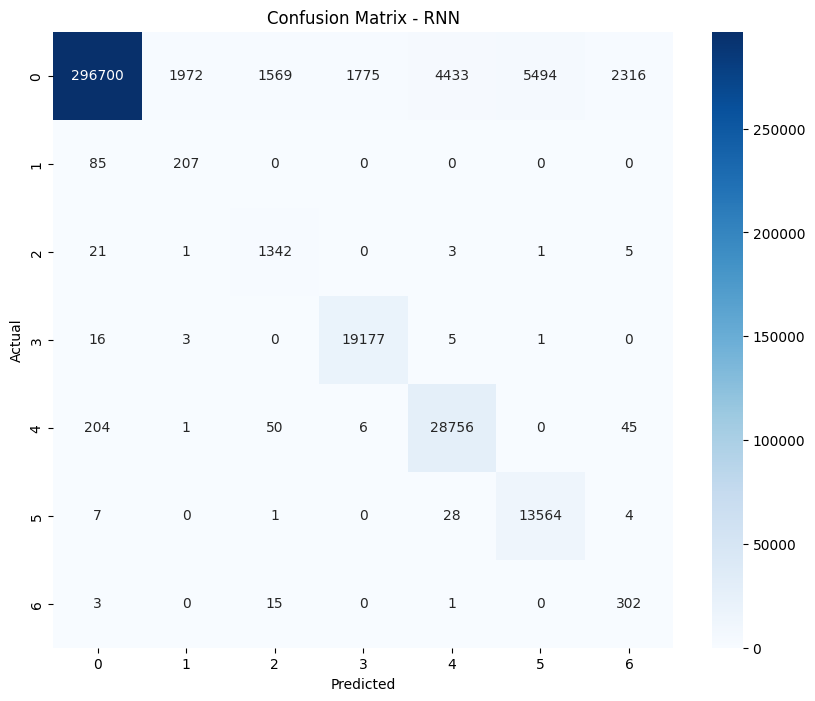

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - RNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

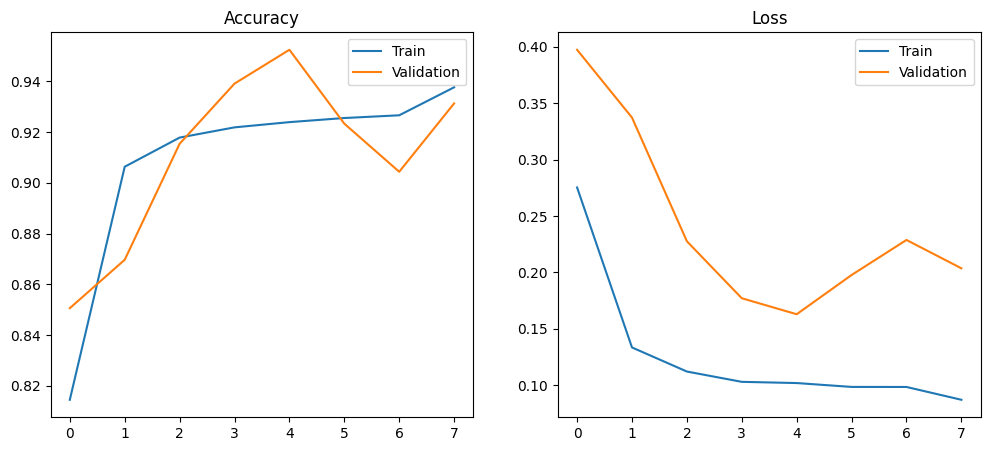

In [48]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [49]:
# Save in legacy HDF5 format
model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\rnn\rnn_model.h5")

# Save in native Keras format (recommended)
model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\rnn\rnn_model.keras")

print("Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.")

Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.


<h1><center>TYPE 2 - TRAINING MODEL WITH SELECTED TOP 35 FEATURES</h1></center>

<h3>STEP 1 - Load Dataset</h3>

In [50]:
import pandas as pd

data_top_sec = pd.read_csv(r'D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\Data\processed_04\cicids2017_selected_top_features.csv')

print(data_top_sec.shape)

(2520751, 36)


</h3>STEP 2 – Separate X and y</h3>

In [51]:
X = data_top_sec.drop('Encoded_Label', axis=1)
y = data_top_sec['Encoded_Label']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2520751, 35)
y shape: (2520751,)


<h3>STEP 3 – Scale (float32 for memory efficiency)</h3>

In [52]:
from sklearn.preprocessing import StandardScaler
import joblib
import numpy as np

# Ensure X only contains numeric features
X = X.select_dtypes(include=[np.number]).astype(np.float32)

# Fit and transform with StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save the scaler for later use
joblib.dump(scaler, r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\rnn_scaler_top_sec.pkl")

print("Scaling complete. Scaler saved successfully.")

Scaling complete. Scaler saved successfully.


<h3>STEP 4 – Train / Validation / Test Split</h3>

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1764525, 35)
Validation: (378113, 35)
Test: (378113, 35)


<h3>STEP 5 – Compute & Clamp Class Weights</h3>

In [54]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

# Clamp extreme weights to prevent instability
class_weights_dict = {
    k: min(v, 50)
    for k, v in class_weights_dict.items()
}

print("Final Class Weights:")
print(class_weights_dict)

Final Class Weights:
{0: np.float64(0.17188427992709365), 1: 50, 2: np.float64(39.3559718969555), 3: np.float64(2.8130231001004353), 4: np.float64(1.8586723295064924), 5: np.float64(3.9705604385218787), 6: 50}


<h3>STEP 6 – Reshape for RNN</h3>

In [55]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val   = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("Reshaped Train:", X_train.shape)

Reshaped Train: (1764525, 35, 1)


<h3>STEP 7 - Build RNN with input shape of 35</h3>

In [56]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

num_classes = 7

model = Sequential([
    Input(shape=(35,1)),
    
    SimpleRNN(64, activation='tanh'),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    Dropout(0.3),
    
    Dense(num_classes, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005,   # Reduced LR
    clipnorm=1.0            # Gradient clipping
)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,839 (34.53 KB)

 Trainable params: 8,839 (34.53 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [58]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=1024,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 36s 20ms/step - accuracy: 0.7990 - loss: 0.3293 - val_accuracy: 0.8793 - val_loss: 0.3324 - learning_rate: 5.0000e-04
Epoch 2/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.8913 - loss: 0.1448 - val_accuracy: 0.8949 - val_loss: 0.2770 - learning_rate: 5.0000e-04
Epoch 3/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9070 - loss: 0.1145 - val_accuracy: 0.9101 - val_loss: 0.2432 - learning_rate: 5.0000e-04
Epoch 4/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9109 - loss: 0.1047 - val_accuracy: 0.9110 - val_loss: 0.2478 - learning_rate: 5.0000e-04
Epoch 5/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9162 - loss: 0.0971 - val_accuracy: 0.9289 - val_loss: 0.2106 - learning_rate: 5.0000e-04
Epoch 6/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9192 - loss: 0.0946 - val_accuracy: 0.9214 - val_loss: 0.2186 - learning_rate: 5.0000e-04
Epoch 7/15
1724/1724 ━━━━━━━━━━━━━━━━━━━

<h3>STEP 8 - RNN EVALUATION</h3>

In [59]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print("\nTest Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

11817/11817 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9524 - loss: 0.1344

Test Accuracy: 0.9523634314537048
Test Loss: 0.13442930579185486


In [60]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test, batch_size=1024)
y_pred_classes = y_pred.argmax(axis=1)

print(classification_report(y_test, y_pred_classes, digits=4))

370/370 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
              precision    recall  f1-score   support

           0     0.9996    0.9435    0.9707    314259
           1     0.0522    0.9658    0.0990       292
           2     0.7263    0.9701    0.8307      1373
           3     0.9107    0.9991    0.9528     19202
           4     0.8886    0.9959    0.9392     29062
           5     0.7256    0.9965    0.8397     13604
           6     0.1624    0.9782    0.2786       321

    accuracy                         0.9524    378113
   macro avg     0.6379    0.9784    0.7015    378113
weighted avg     0.9742    0.9524    0.9609    378113



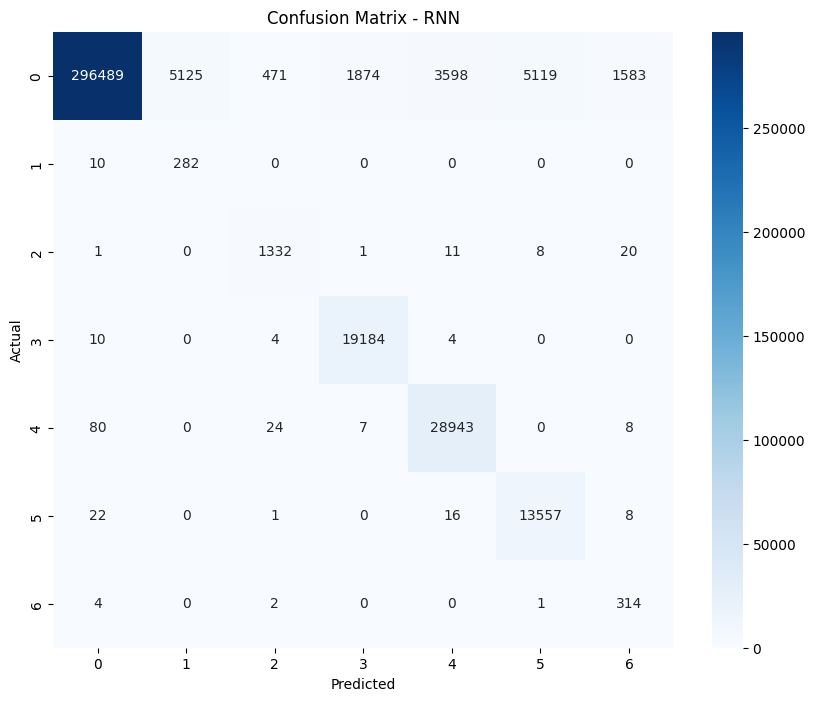

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - RNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [62]:
# Save in legacy HDF5 format
model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\rnn\rnn_top_sec_model.h5")

# Save in native Keras format (recommended)
model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\rnn\rnn_top_sec_model.keras")

print("Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.")

Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.
